In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
sys.path.append("/content/drive/MyDrive/ColabNotebooks MachineLearning")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import  logistic_regression as log_reg
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc,roc_curve
from sklearn.model_selection import RandomizedSearchCV

In [4]:
df = pd.read_csv("/content/drive/MyDrive/ColabNotebooks MachineLearning/Dataset/health_lifestyle_classification.csv")
pd.set_option("display.max_columns", None)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   survey_code               100000 non-null  int64  
 1   age                       100000 non-null  int64  
 2   gender                    100000 non-null  object 
 3   height                    100000 non-null  float64
 4   weight                    100000 non-null  float64
 5   bmi                       100000 non-null  float64
 6   bmi_estimated             100000 non-null  float64
 7   bmi_scaled                100000 non-null  float64
 8   bmi_corrected             100000 non-null  float64
 9   waist_size                100000 non-null  float64
 10  blood_pressure            92331 non-null   float64
 11  heart_rate                85997 non-null   float64
 12  cholesterol               100000 non-null  float64
 13  glucose                   100000 non-null  fl

**Analisi struttura Dataset**<br>
Il numero totale di campioni del dataset è 100k, mentre il numero di features è 48 di cui una è la label.
Ad una prima analisi, si evidenzia un insieme di features eterogenee, numeriche(es. age) e categoriche(es. occupation).Questa diversità implica la necessità di un preprocessing ad hoc per ognuna di esse.

**Analisi dei valori nulli presenti nel dataset**<br>
L'analisi preliminare mostra che i valori mancanti sono eterogenei in quantità e sono legati a features diverse (categoriche e non). Quindi vanno gestiti con attenzione, effettuando un'analisi specifica per ogni feature.




In [5]:
df.head(10)

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,sleep_quality,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,stress_level,mental_health_score,mental_health_support,education_level,job_type,occupation,income,diet_type,exercise_type,device_usage,healthcare_access,insurance,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage,target
0,1,56,Male,173.416872,56.886640,18.915925,18.915925,56.747776,18.989117,72.165130,118.264254,60.749825,214.580523,103.008176,NaN,6.475885,Fair,7.671313,0.356918,13320.942595,2673.546960,44.476887,NaN,Non-smoker,1.694262,5.003963,2,8,No,PhD,Tech,Farmer,6759.821719,Vegan,Strength,High,Poor,No,High,5,Moderate,No,Yes,0,1.0,5.5,-2.275502,healthy
1,2,69,Female,163.207380,97.799859,36.716278,36.716278,110.148833,36.511417,85.598889,117.917986,66.463696,115.794002,116.905134,10.131597,8.428410,Good,9.515198,0.568219,11911.201401,2650.376972,74.663405,Regularly,Light,0.716409,5.925455,3,9,No,High School,Office,Engineer,6240.517690,Vegan,Cardio,Moderate,Moderate,No,High,5,High,Yes,No,0,1.0,5.5,6.239340,healthy
2,3,46,Male,177.281966,80.687562,25.673050,25.673050,77.019151,25.587429,90.295030,123.073698,76.043212,138.134787,89.180302,NaN,5.702164,Poor,5.829853,3.764406,2974.035375,1746.755144,19.702382,Regularly,Heavy,2.487900,4.371250,0,1,No,Master,Office,Teacher,3429.179266,Vegan,Cardio,High,Good,Yes,High,4,Moderate,No,No,0,1.0,5.5,5.423737,healthy
3,4,32,Female,172.101255,63.142868,21.318480,21.318480,63.955440,21.177109,100.504211,148.173453,68.781981,203.017447,128.375798,18.733179,5.188316,Good,9.489693,0.889474,5321.539497,2034.193242,82.580050,Occasionally,Heavy,2.643335,4.116064,10,4,No,Master,Labor,Teacher,2618.503534,Vegetarian,Mixed,Low,Moderate,No,High,1,NaN,No,Yes,0,1.0,5.5,8.388611,healthy
4,5,60,Female,163.608816,40.000000,14.943302,14.943302,44.829907,14.844299,69.021150,150.613181,92.335358,200.412439,94.813332,16.038701,7.912514,Good,7.275450,2.901608,9791.376712,2386.210257,45.961322,NaN,Heavy,1.968393,3.180087,9,7,Yes,Master,Unemployed,Doctor,3662.086276,Vegan,NaN,Low,Moderate,Yes,High,1,High,Yes,Yes,0,1.0,5.5,0.332622,healthy
5,6,25,Male,186.788025,55.276111,15.843073,15.843073,47.529218,16.087835,86.591923,118.722971,51.971485,165.659179,99.496769,NaN,10.065352,Poor,8.536500,3.581308,9221.120390,2565.731983,71.999679,Occasionally,Heavy,2.115213,5.878847,7,6,No,High School,Office,Teacher,3667.151536,Vegetarian,NaN,Low,Moderate,Yes,High,4,NaN,Yes,Yes,0,1.0,5.5,-8.985465,healthy
6,7,78,Female,166.164733,65.035212,23.554335,23.554335,70.663006,23.452755,67.838374,102.141757,70.472631,245.801110,91.821000,15.583876,4.342973,Excellent,6.206772,0.294640,7968.302176,1868.203785,53.836960,Occasionally,Heavy,1.704180,4.418494,7,1,Yes,Bachelor,Unemployed,Engineer,3898.829196,Vegetarian,Strength,Moderate,Poor,Yes,High,2,NaN,No,No,0,NaN,5.5,-6.296536,healthy
7,8,38,Female,163.783995,47.756125,17.802712,17.802712,53.408136,17.654781,73.071574,136.790243,65.791315,157.519344,106.466414,12.736925,6.659164,Poor,9.181722,1.783920,3606.509508,1885.142923,73.716032,NaN,Non-smoker,1.575306,8.298021,7,2,No,Bachelor,Tech,Farmer,3360.848318,Omnivore,Strength,High,Moderate,Yes,Low,3,Moderate,No,Yes,0,1.0,5.5,7.875266,healthy
8,9,56,Female,165.716460,47.257109,17.208216,17.208216,51.624648,17.199712,46.675208,133.536300,78.205237,160.148783,78.770043,NaN,8.717906,Poor,11.461929,0.838778,5199.027338,1642.194189,84.438878,Occasionally,Light,2.337446,0.707336,2,9,Yes,PhD,Office,Engineer,5366.332772,Vegan,NaN,High,Moderate,Yes,High,2,Moderate,No,No,0,NaN,5.5,-8.055654,healthy
9,10,75,Male,151.310888,65.966591,28.812682,28.812682,86.438045,29.088049,94.294368,121.761602,90.470232,192.111798,130.681356,NaN,8.184905,Fair,4.638267,2

**Analisi prime righe del dataset**<br>
Dall'analisi delle prime righe del Dataset si possono notare alcune anomalie e feature potenzialmente non informative per la classificazione del target:<br>
*   **survey_code**: è un identificativo incrementale per ogni riga del dataset.
*   **environmental_risk_score**, **gene_marker_flag** ed **electrolyte_level**: sembrano essere sempre costanti o contenere dei valori nulli tra quelli costanti.

*  Incoerenza tra **job_type** e **occupation**.
*   valori negativi in **daily_supplement_dosage** non coerenti con il significato della feature.

*   Valori mancanti nelle features categoriche.

*  Scale eterogenee nelle feature numeriche.


In [6]:
df.describe()

,survey_code,age,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,water_intake,screen_time,stress_level,mental_health_score,income,meals_per_day,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,92331.000000,85997.000000,100000.000000,100000.000000,84164.000000,100000.000000,100000.000000,100000.000000,91671.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,91530.000000,100000.000000,100000.0,89526.0,100000.0,100000.000000
mean,50000.500000,48.525990,170.023707,70.064862,24.493876,24.493876,73.481627,24.494140,84.933043,119.980149,74.969177,189.966438,99.994538,14.988258,7.002008,8.001331,3.038344,7012.925748,2201.428579,60.047165,2.006373,6.021525,4.991600,5.004680,4038.127284,2.998720,0.0,1.0,5.5,0.015726
std,28867.657797,17.886768,9.982798,14.693667,5.951069,5.951069,17.853206,5.954184,12.040314,15.015503,9.941668,29.981934,19.982828,5.002783,1.496821,1.994723,1.884475,2488.989356,400.516318,19.966850,0.688868,2.933835,3.154997,3.164228,1930.025678,1.414786,0.0,0.0,0.0,5.764489
min,1.000000,18.000000,140.000000,40.000000,9.988495,9.988495,29.965484,9.893845,34.093185,59.128168,34.745092,58.410902,12.434931,-6.794483,3.000000,0.000000,0.000000,1000.000000,527.172360,-27.882444,0.500000,0.000000,0.000000,0.000000,500.000000,1.000000,0.0,1.0,5.5,-9.999895
25%,25000.750000,33.000000,163.306615,59.856938,20.271405,20.271405,60.814215,20.271059,76.795185,109.812060,68.275432,169.667738,86.461401,11.627114,5.986781,6.651093,1.633799,5320.858377,1932.278165,46.504292,1.532011,3.971318,2.000000,2.000000,2665.402843,2.000000,0.0,1.0,5.5,-4.980501
50%,50000.500000,48.000000,170.016778,69.924141,24.156734,24.156734,72.470201,24.151699,84.957139,119.951794,75.046211,190.044579,99.986834,14.983414,6.998164,8.004549,2.971222,7004.285450,2200.992765,60.047905,2.000659,5.991171,5.000000,5.000000,4004.601345,3.000000,0.0,1.0,5.5,0.015589
75%,75000.250000,64.000000,176.728920,80.027418,28.258696,28.258696,84.776088,28.247648,93.018713,130.120621,81.685914,210.222005,113.508722,18.361928,8.019219,9.353669,4.326500,8702.281300,2471.218160,73.476386,2.473047,8.024470,8.000000,8.000000,5360.012694,4.000000,0.0,1.0,5.5,5.008424
max,100000.000000,79.000000,210.000000,139.250894,59.234792,59.234792,177.704377,59.142646,133.153631,184.439195,114.136041,319.875613,183.883548,35.464749,12.000000,16.000000,11.631898,18064.969543,3949.019017,141.514522,5.000000,16.000000,10.000000,10.000000,12029.409353,5.000000,0.0,1.0,5.5,9.999966


**Analisi metriche Features**<br>
L'analisi delle metriche descrittive evidenziano la presenza di feature costanti (**environmental_risk_score**, **gene_marker_flag** ed **electrolyte_level**) e di un identificativo(**survey_code**) che verranno rimossi. Alcune feature presentano valori negativi, impossibili e da correggere (**sugar_intake**, **insulin** e **daily_supplement_dosage**). Sono presenti alcune variabili ridondanti(bmi_*).

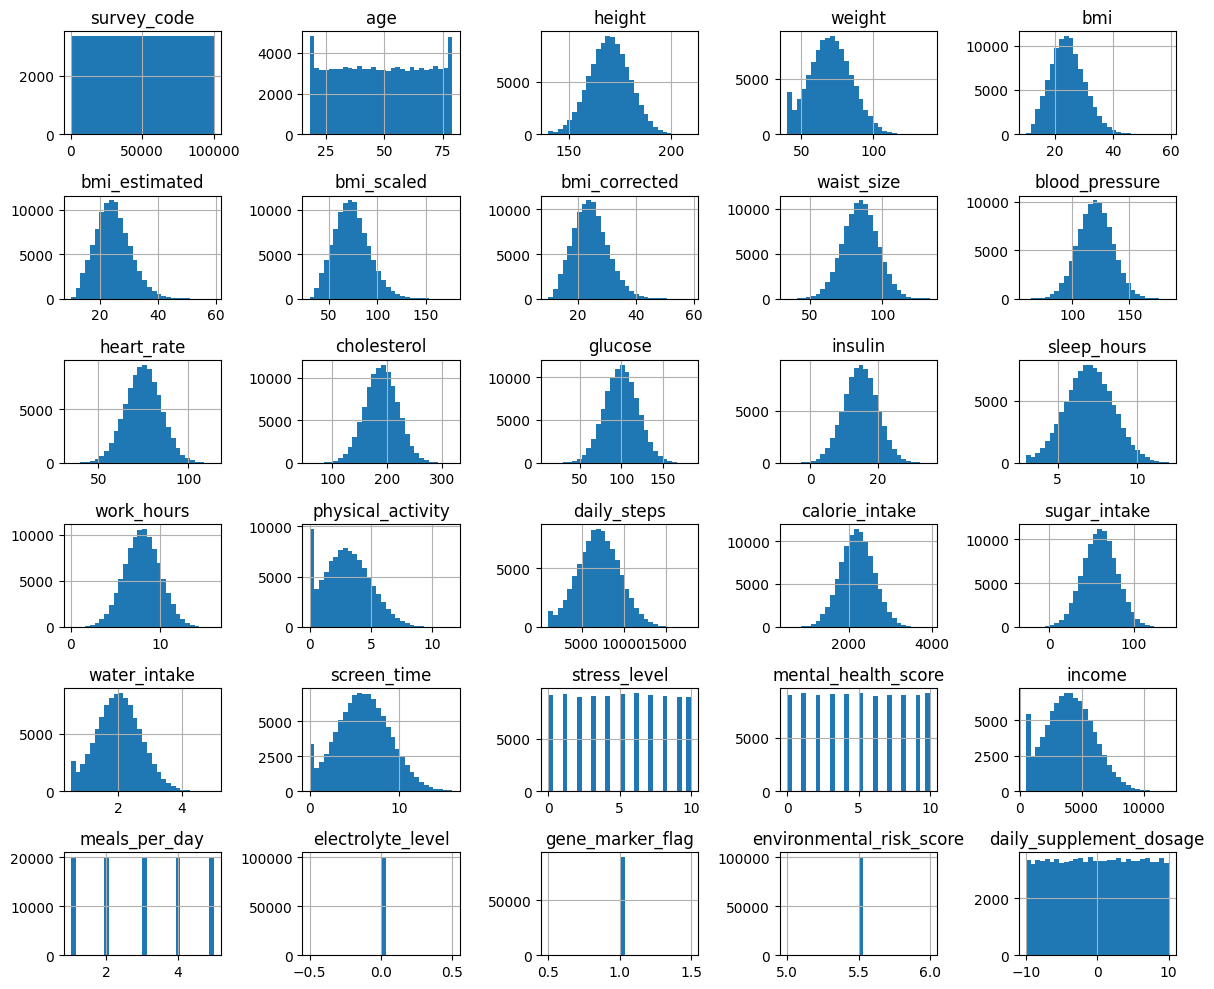

In [7]:
# Istogrammi di tutte le variabili numeriche per analizzare la forma delle distribuzioni
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols].hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()



Le distribuzioni evidenziano una forte eterogeneità: alcune feature risultano degenerate (un solo valore osservato), altre presentano valori negativi, e molte mostrano una forma simmetrica e approssimativamente normale. Questo conferma quanto emerso dalle statistiche descrittive. La presenza diffusa di features gaussiane rende appropriati algoritmi come **LDA** e **Gaussian Naive Bayes**, che utilizzano tali assunzioni.


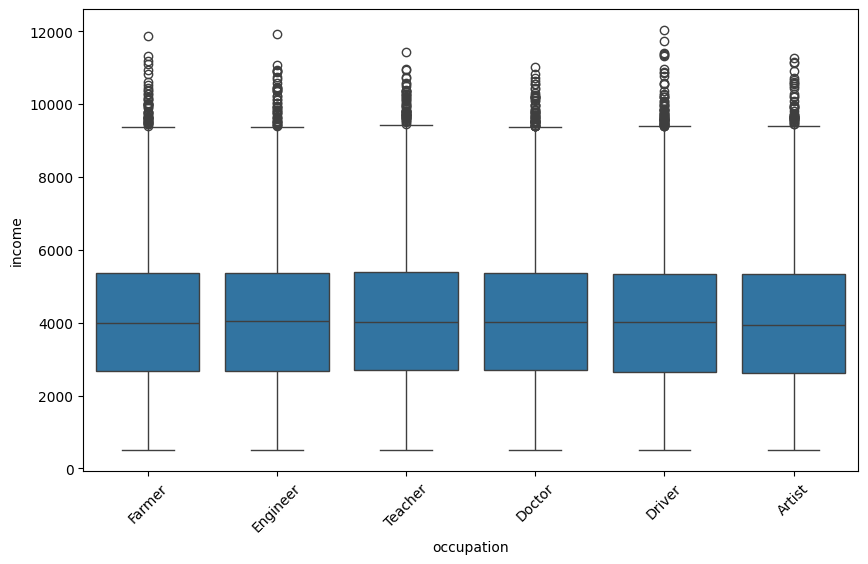

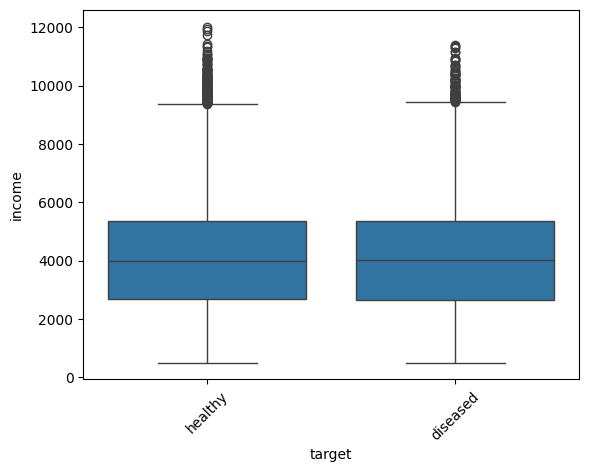

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="occupation", y="income")
plt.xticks(rotation=45)
plt.show()

sns.boxplot(x=df["target"], y=df["income"])
plt.xticks(rotation=45)
plt.show()

I boxplot di **income** suddivisi per **occuaption** risultano praticamente identici. Questo indica che income è stata generate sinteticamente senza differenze salariali tra le categorie lavorative. Non variando nemmeno rispetto alla variabile target non rappresenta informazione utile alla classificazione e può essere rimossa.

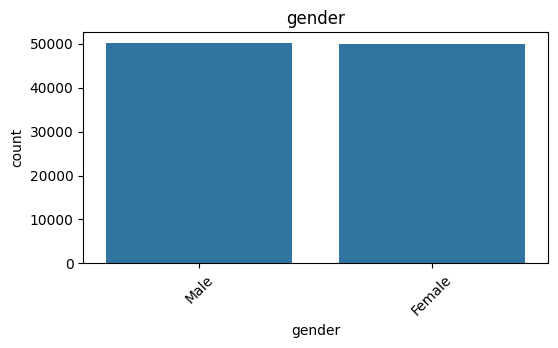

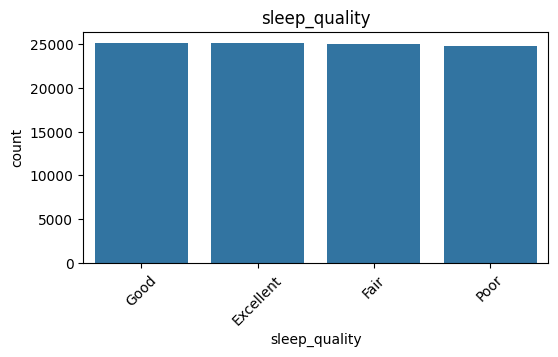

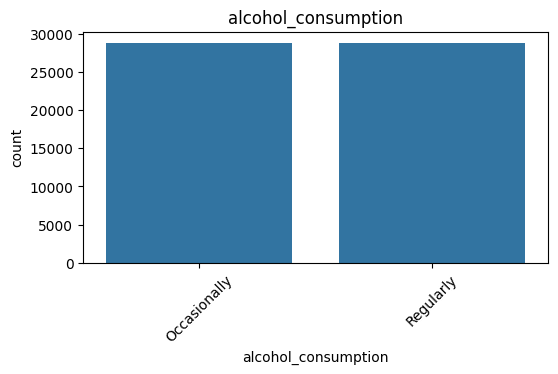

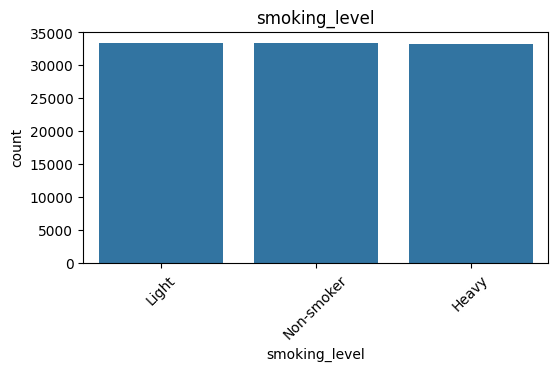

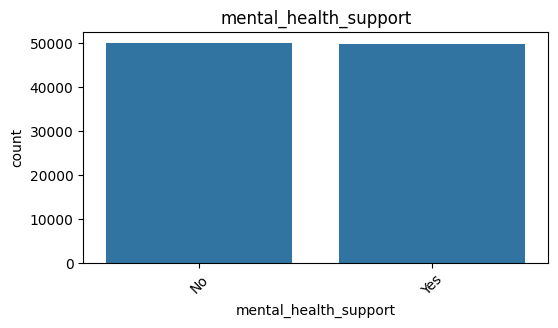

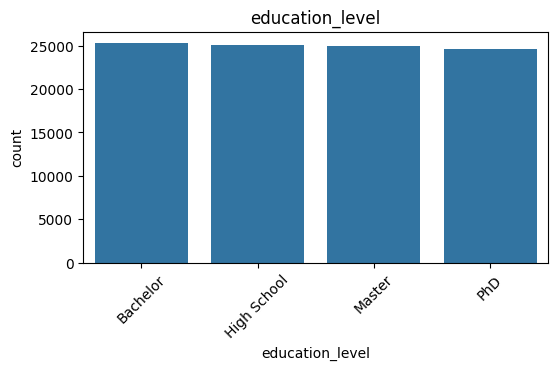

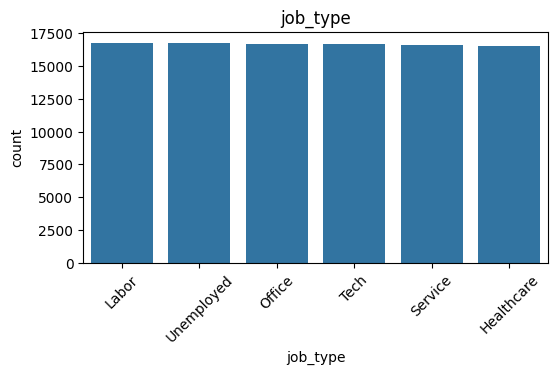

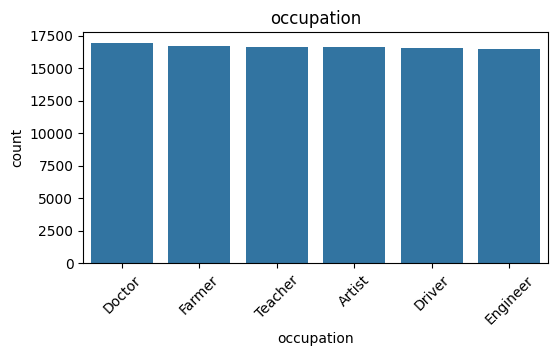

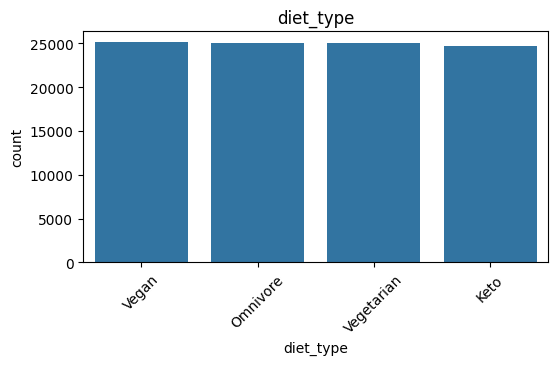

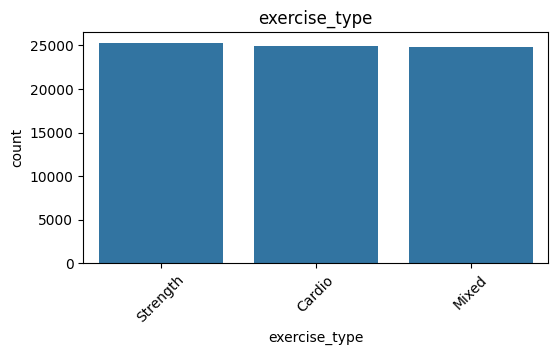

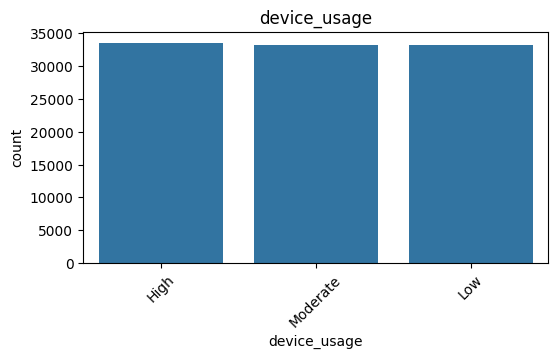

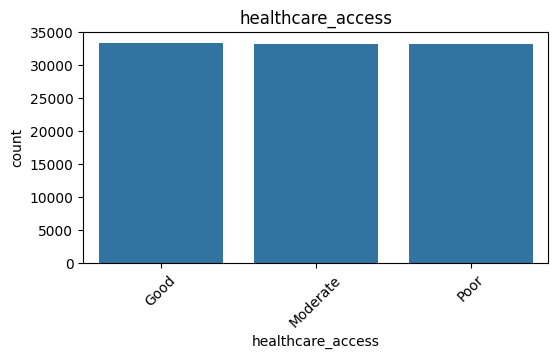

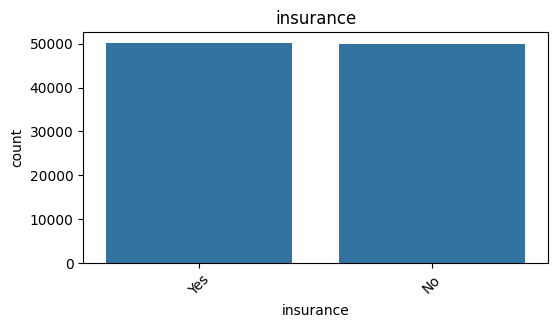

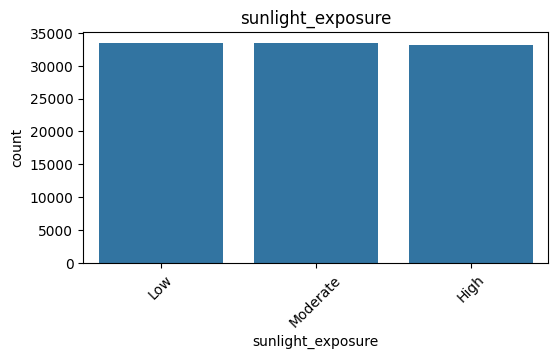

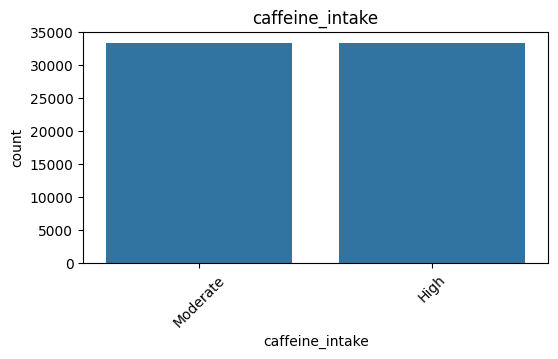

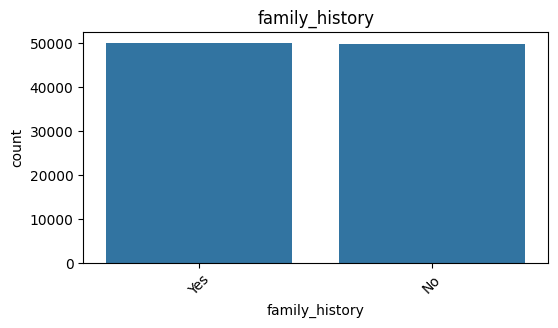

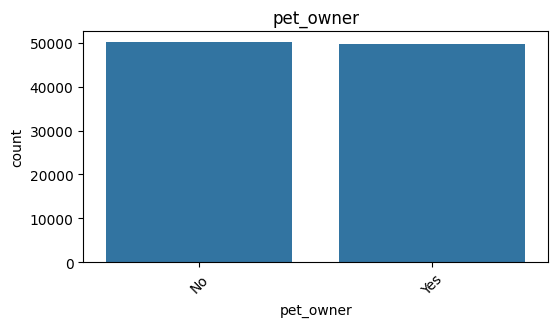

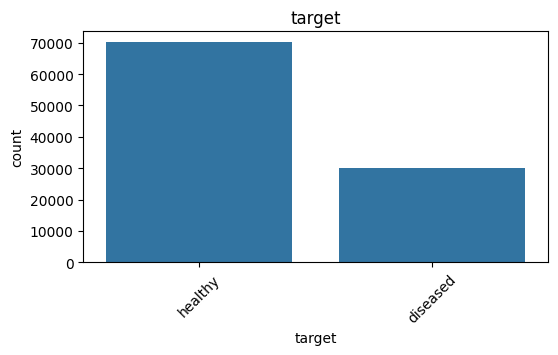

In [9]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()



Le variabili categoriche mostrano distribuzioni equilibrate e un numero ridotto di categorie (al massimo 6 per singola feature). Non sono presenti sbilanciamenti significativi. Si ritiene appropriato l' utilizzo di un preprocesing con One-Hot-Encoding. L'assenza di sbilanciamento nelle categorie non introduce bias nei modelli.

In [10]:
#Eliminazione di feature correlate con bmi e feature ID del dataset
df = df.drop("survey_code", axis=1)
df = df.drop("bmi_estimated", axis=1)
df = df.drop("bmi_scaled", axis=1)
df = df.drop("bmi_corrected", axis=1)


#La colonna gene_marker_flag o è nulla o ha tutti 1 --- non porta info quindi la elimino
#Anche environmental_risk_score  electrolyte_level
df = df.drop("gene_marker_flag", axis=1)
df = df.drop("environmental_risk_score", axis=1)
df = df.drop("electrolyte_level", axis=1)

#Molte volte la colonna job_type è incoerente con Occupation
#Inoltre l'occupazione è più utile per discriminare la presenza di problemi di salute piuttosto che il campo lavorativo
df = df.drop("job_type", axis=1)

#income ha la stessa distribuzione per ogni occupation
df = df.drop("income", axis=1)

In [11]:
 #MISSING VALUES
df["blood_pressure"] = df["blood_pressure"].fillna(df["blood_pressure"].mean())
df["heart_rate"] = df["heart_rate"].fillna(df["heart_rate"].mean())
df["insulin"] = df["insulin"].fillna(df["insulin"].mean())
df['daily_steps'] = df['daily_steps'].fillna(df['daily_steps'].mean())

In [12]:
# Gestione valori negativi di insulin e daily_supplement_dosage
df["insulin"] = df["insulin"].mask(df["insulin"] < 0, np.nan)
df["insulin"] = df["insulin"].fillna(df["insulin"].median())
df["daily_supplement_dosage"] = df["daily_supplement_dosage"].mask(df["daily_supplement_dosage"] < 0, np.nan)
df["daily_supplement_dosage"] = df["daily_supplement_dosage"].fillna(df["daily_supplement_dosage"].median())


In [13]:
#FEATURES BINARIE
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})
df["mental_health_support"] = df["mental_health_support"].map({"Yes": 1, "No": 0})
df["insurance"] = df["insurance"].map({"Yes": 1, "No": 0})
df["family_history"] = df["family_history"].map({"Yes": 1, "No": 0})
df["pet_owner"] = df["pet_owner"].map({"Yes": 1, "No": 0})
df["target"] = df["target"].map({"diseased": 1, "healthy": 0})

In [14]:
categorical_cols = ["sleep_quality","smoking_level","device_usage","healthcare_access",
    "sunlight_exposure","alcohol_consumption","education_level","occupation",
    "diet_type","exercise_type","caffeine_intake"]

for col in categorical_cols:
    print(f"\nValori unici per {col}:")
    print(df[col].unique())



Valori unici per sleep_quality:
['Fair' 'Good' 'Poor' 'Excellent']

Valori unici per smoking_level:
['Non-smoker' 'Light' 'Heavy']

Valori unici per device_usage:
['High' 'Moderate' 'Low']

Valori unici per healthcare_access:
['Poor' 'Moderate' 'Good']

Valori unici per sunlight_exposure:
['High' 'Low' 'Moderate']

Valori unici per alcohol_consumption:
[nan 'Regularly' 'Occasionally']

Valori unici per education_level:
['PhD' 'High School' 'Master' 'Bachelor']

Valori unici per occupation:
['Farmer' 'Engineer' 'Teacher' 'Doctor' 'Driver' 'Artist']

Valori unici per diet_type:
['Vegan' 'Vegetarian' 'Omnivore' 'Keto']

Valori unici per exercise_type:
['Strength' 'Cardio' 'Mixed' nan]

Valori unici per caffeine_intake:
['Moderate' 'High' nan]


In [15]:
#FEATURES ORDINALI
df["sleep_quality"] = df["sleep_quality"].map({"Poor": 0,"Fair": 1,"Good": 2,"Excellent":3})
df["smoking_level"] = df["smoking_level"].map({"Non-smoker": 0, "Light": 1, "Heavy": 2})
df["device_usage"] = df["device_usage"].map({"Low": 0, "Moderate": 1, "High": 2})
df["healthcare_access"] = df["healthcare_access"].map({"Poor": 0, "Moderate": 1, "Good": 2})
df["sunlight_exposure"] = df["sunlight_exposure"].map({"Low": 0, "Moderate": 1, "High": 2})

In [16]:
#FEATURES NOMINALI

#alcohol_consumption
df["alcohol_missing_flag"] = df["alcohol_consumption"].isnull()
# Distribuzione del target tra missing e non missing
print("\nDistribuzione target per alcohol_consumption (missing vs non-missing):")
print(df.groupby("alcohol_missing_flag")["target"].value_counts(normalize=True) * 100)
# I missing non sono informativi: la distribuzione healthy/diseased è identica
# quindi non rappresentano implicitamente il "non consumo"
df["alcohol_consumption"] = df["alcohol_consumption"].fillna("Missing")
df = df.drop("alcohol_missing_flag", axis=1)


#exercise_type
df["exercise_missing_flag"] = df["exercise_type"].isnull()
print("\nDistribuzione target per exercise_type (missing vs non-missing):")
print(df.groupby("exercise_missing_flag")["target"].value_counts(normalize=True) * 100)
# I missing non sono informativi: imputazione con categoria esplicita
df["exercise_type"] = df["exercise_type"].fillna("Missing")
df = df.drop("exercise_missing_flag", axis=1)


#caffeine_intake
df["caffeine_missing_flag"] = df["caffeine_intake"].isnull()
#Distribuzione del target tra missing e non missing
print("\nDistribuzione target per caffeine_intake (missing vs non-missing):")
print(df.groupby("caffeine_missing_flag")["target"].value_counts(normalize=True) * 100)
#Anche qui i missing non sono informativi:imputazione con categoria esplicita
df["caffeine_intake"] = df["caffeine_intake"].fillna("Missing")
df = df.drop("caffeine_missing_flag", axis=1)


Distribuzione target per alcohol_consumption (missing vs non-missing):
alcohol_missing_flag  target
False                 0         70.395570
                      1         29.604430
True                  0         69.691179
                      1         30.308821
Name: proportion, dtype: float64

Distribuzione target per exercise_type (missing vs non-missing):
exercise_missing_flag  target
False                  0         70.091029
                       1         29.908971
True                   0         70.114943
                       1         29.885057
Name: proportion, dtype: float64

Distribuzione target per caffeine_intake (missing vs non-missing):
caffeine_missing_flag  target
False                  0         69.969583
                       1         30.030417
True                   0         70.352665
                       1         29.647335
Name: proportion, dtype: float64


Per la feature **alcohol_consumption** è stata verificata l'informatività dei missing. Se fosse stata sbilanciata, probabilmente i valori mancanti avrebbero indicato il non consumo di alcohol. Ma ala distribuzione tra disease/healty è la stessa quindi si è deciso di imputare con valore "Missing". Stesso ragionamento per **caffeine_intake** e **excercise_type**.

In [17]:
#ONE HOT ENCODING
df = pd.get_dummies(df, columns=["alcohol_consumption"], drop_first=True, dtype=int)
df = pd.get_dummies(df, columns=["education_level"], drop_first=True, dtype=int)
df = pd.get_dummies(df, columns=["occupation"], drop_first=True, dtype=int)
df = pd.get_dummies(df, columns=["diet_type"], drop_first=True, dtype=int)
df = pd.get_dummies(df, columns=["exercise_type"], drop_first=True, dtype=int)
df = pd.get_dummies(df, columns=["caffeine_intake"], drop_first=True, dtype=int)

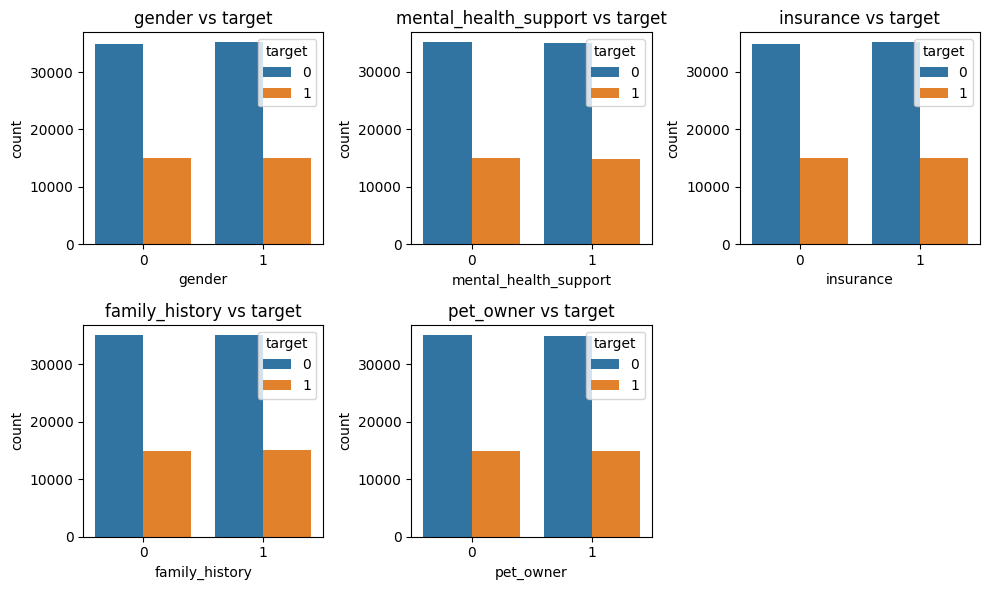

In [18]:
#Countplot feature binarie - target
binary_cols = ["gender", "mental_health_support", "insurance",
               "family_history", "pet_owner"]
plt.figure(figsize=(10, 6))
for i, col in enumerate(binary_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=df[col], hue=df["target"])
    plt.title(f"{col} vs target")

plt.tight_layout()
plt.show()

Le features binarie mostrano distribuzioni identiche nei due gruppi del target, indicando che non possiedono l'informazione necessaria per discriminare le classi. Questo comportamento è coerente con la natura sintetica del dataset, in cui tali features non sono state generate con una struttura informativa rispetto alla variabile di interesse.
Nonostante la scarsa informatività, tali feature vengono mantenute poiché non introducono sbilanciamenti e possono comunque essere integrate nei modelli senza effetti negativi.

In [19]:
#FEATURES ENGINEERING

df["smoking_stress_level"] = df["smoking_level"] * df["stress_level"]
df["glucose_to_sugar_ratio"] = df["glucose"] / (df["sugar_intake"] + 1e-6)
df["hydration_per_weight"] = df["water_intake"] / (df["weight"]*0.03 + 1e-6)
df["sugar_calorie"] = (df["sugar_intake"] * 4) / df["calorie_intake"]
df["sedentary_index"] = df["device_usage"] * df["screen_time"]
df["sugar_per_meal"] = df["sugar_intake"] / (df["meals_per_day"] + 1e-6)

# Estrazione della colonna target e inserimento alla fine
target_col = df.pop("target")
df.insert(len(df.columns), "target", target_col)

Sono state introdottte nuove features derivate. Queste includono indicatori nutrizionali, misure di sedentarietà,indicatori di idratazioni e variabili normalizzate per il nuimero di pasti. L'obiettivo è quello di arricchire il dataset con informazioni aggiuntive migliorando il potenziale discriminativo dei modelli.

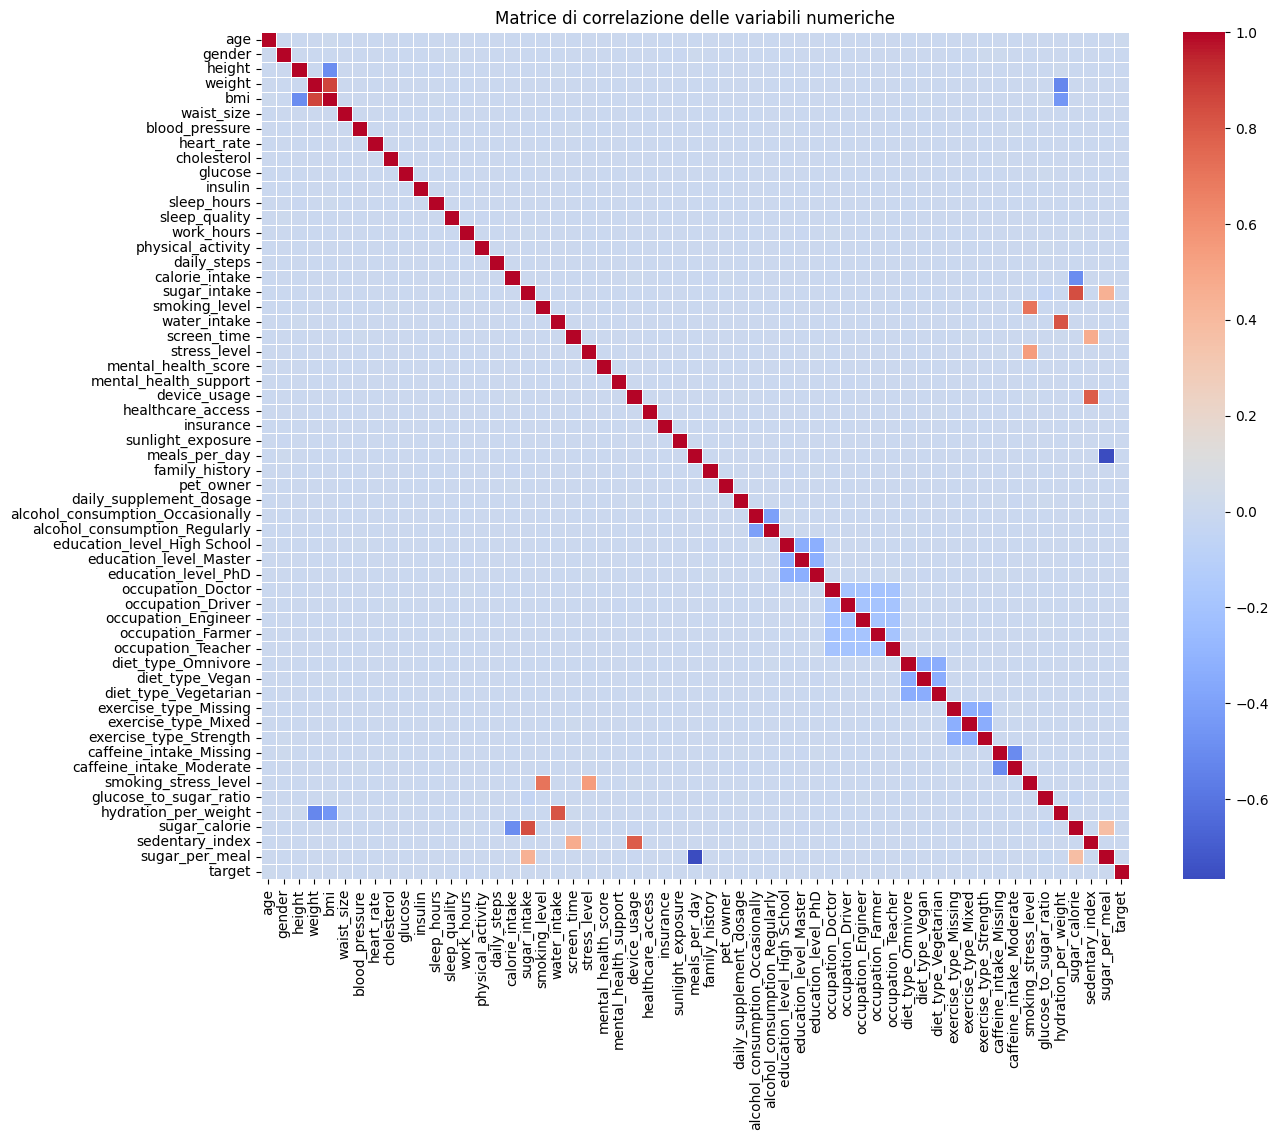

In [20]:
target_col = df.pop("target")
df.insert(len(df.columns), "target", target_col)

# Seleziona solo le colonne numeriche
corr_matrix = df.corr()

# Plot della heatmap
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=False, fmt=".1f", cmap="coolwarm", linewidths=0.5)
plt.title("Matrice di correlazione delle variabili numeriche")
plt.show()


La matricce di correlazioine mostra valori prossimi allo zero tra tutte le features e il target. Questo dimostra l'assenza di relazioni lineari e l'impossibilità di separazione lineare. Ci si aspetta che i modelli lineari come la Logistic Regression mostri performance vicino al caso. L'obiettivo è verificare empiricamente questa ipotesi.

In [21]:
#Separazione training set - validation set - test set
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

X = df.drop("target", axis=1)
y = df["target"]

X_temp, X_test, y_temp, y_test = train_test_split(X, y,test_size=0.20,stratify=y,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp,test_size=0.25,stratify=y_temp,random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (60000, 56)
Validation: (20000, 56)
Test: (20000, 56)


In [22]:
#Normalizzazione dei dati
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


In [23]:
# Addestramento Logistic Regression con varie learning rate

alpha_list = [0.1,0.01, 0.001]
models = {}

import warnings
warnings.filterwarnings('ignore')

for alpha in alpha_list:

    # Inizializzo i pesi
    W = np.zeros(X_train_scaled.shape[1])

    max_iter = 3000
    for _ in range(max_iter):
        grad = log_reg.vectorized_gradient(W, X_train_scaled, y_train.values)
        W = W - alpha * grad

    #Salvo i pesi dei modelli
    models[alpha] = W.copy()


MODELLO con alpha = 0.1
AUPRC Validation set: 0.3045
AUC ROC su validation Set: 0.5110

--- Soglia = 0.2 ---
TP: 5980, FP: 14020
FN: 0, TN: 0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     14020
           1       0.30      1.00      0.46      5980

    accuracy                           0.30     20000
   macro avg       0.15      0.50      0.23     20000
weighted avg       0.09      0.30      0.14     20000


--- Soglia = 0.5 ---
TP: 0, FP: 0
FN: 5980, TN: 14020
              precision    recall  f1-score   support

           0       0.70      1.00      0.82     14020
           1       0.00      0.00      0.00      5980

    accuracy                           0.70     20000
   macro avg       0.35      0.50      0.41     20000
weighted avg       0.49      0.70      0.58     20000


--- Soglia = 0.7 ---
TP: 0, FP: 0
FN: 5980, TN: 14020
              precision    recall  f1-score   support

           0       0.70      1.00      

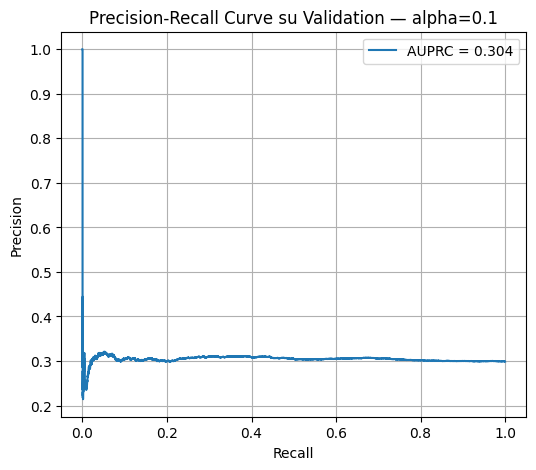

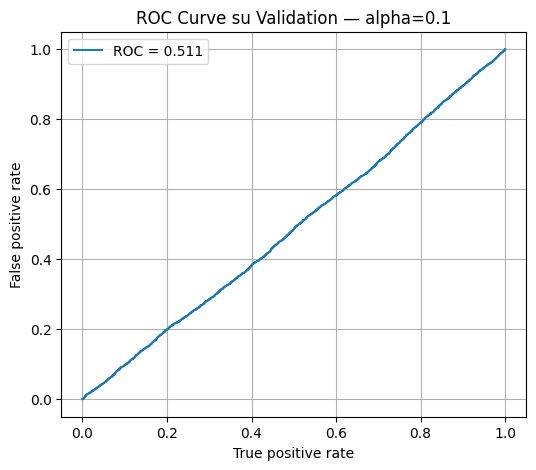

MODELLO con alpha = 0.01
AUPRC Validation set: 0.3051
AUC ROC su validation Set: 0.5060

--- Soglia = 0.2 ---
TP: 5980, FP: 14020
FN: 0, TN: 0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     14020
           1       0.30      1.00      0.46      5980

    accuracy                           0.30     20000
   macro avg       0.15      0.50      0.23     20000
weighted avg       0.09      0.30      0.14     20000


--- Soglia = 0.5 ---
TP: 0, FP: 0
FN: 5980, TN: 14020
              precision    recall  f1-score   support

           0       0.70      1.00      0.82     14020
           1       0.00      0.00      0.00      5980

    accuracy                           0.70     20000
   macro avg       0.35      0.50      0.41     20000
weighted avg       0.49      0.70      0.58     20000


--- Soglia = 0.7 ---
TP: 0, FP: 0
FN: 5980, TN: 14020
              precision    recall  f1-score   support

           0       0.70      1.00     

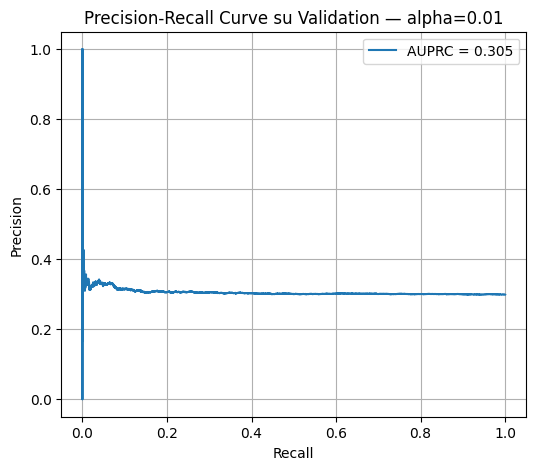

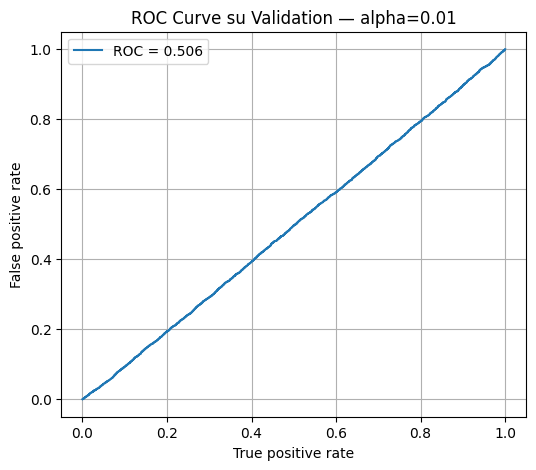

MODELLO con alpha = 0.001
AUPRC Validation set: 0.3031
AUC ROC su validation Set: 0.5027

--- Soglia = 0.2 ---
TP: 5980, FP: 14020
FN: 0, TN: 0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     14020
           1       0.30      1.00      0.46      5980

    accuracy                           0.30     20000
   macro avg       0.15      0.50      0.23     20000
weighted avg       0.09      0.30      0.14     20000


--- Soglia = 0.5 ---
TP: 0, FP: 0
FN: 5980, TN: 14020
              precision    recall  f1-score   support

           0       0.70      1.00      0.82     14020
           1       0.00      0.00      0.00      5980

    accuracy                           0.70     20000
   macro avg       0.35      0.50      0.41     20000
weighted avg       0.49      0.70      0.58     20000


--- Soglia = 0.7 ---
TP: 0, FP: 0
FN: 5980, TN: 14020
              precision    recall  f1-score   support

           0       0.70      1.00    

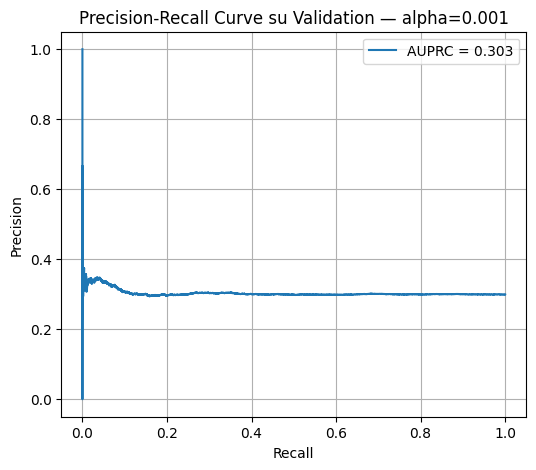

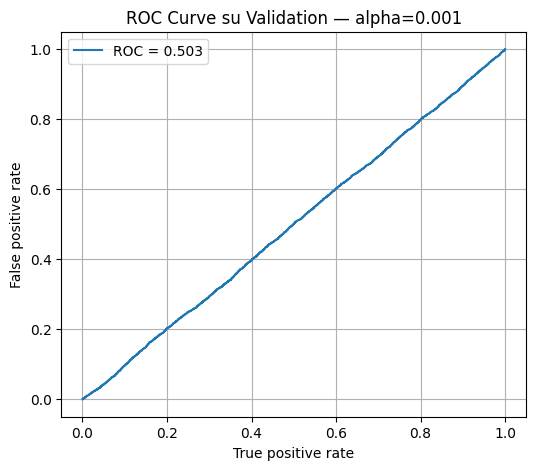

Miglior modello trovato:
alpha: 0.01
AUPRC: 0.30508350571747167
Miglior soglia clinica: 0.2
Falsi negativi: 0


In [24]:

#VALUTAZIONE MODELLI LOGISTIC REGRESSION
threshold_list = [0.2, 0.5, 0.7]
best_model = None
best_alpha = None
best_auprc = -1

est_threshold = None
min_fn = 10**9

for alpha in alpha_list:
    print(f"MODELLO con alpha = {alpha}")

    W = models[alpha]

    # Probabilità sul validation
    probs_val = log_reg.sigmoid(X_val_scaled @ W)

    # PR curve
    precision, recall, _ = precision_recall_curve(y_val, probs_val)
    auprc = auc(recall, precision)
    print(f"AUPRC Validation set: {auprc:.4f}")

    #Sceltas del modello migliore secondo la curvas PR
    if auprc > best_auprc:
          best_auprc = auprc
          best_alpha = alpha
          best_model = W

    # ROC curve
    fpr, tpr, _ = roc_curve(y_val, probs_val)
    auc_roc = auc(fpr, tpr)
    print(f"AUC ROC su validation Set: {auc_roc:.4f}")


    for threshold in threshold_list:

        y_hat = (probs_val >= threshold).astype(int)

        print(f"\n--- Soglia = {threshold} ---")
        cm = confusion_matrix(y_val, y_hat)
        print(f"TP: {cm[1,1]}, FP: {cm[0,1]}")
        print(f"FN: {cm[1,0]}, TN: {cm[0,0]}")

        #Scelta della soglia miglire sulla base della minimizzazione dei FN
        if cm[1,0] < min_fn:
            min_fn = cm[1,0]
            best_threshold = threshold

        print(classification_report(y_val, y_hat))

    # Plot PR curve
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f'AUPRC = {auprc:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve su Validation — alpha={alpha}')
    plt.legend()
    plt.grid(True)
    plt.show()

    #ROC PLOT
    plt.figure(figsize=(6,5))
    plt.plot(tpr, fpr, label=f'ROC = {auc_roc:.3f}')
    plt.xlabel('True positive rate')
    plt.ylabel('False positive rate')
    plt.title(f'ROC Curve su Validation — alpha={alpha}')
    plt.legend()
    plt.grid(True)
    plt.show()


print("Miglior modello trovato:")
print("alpha:", best_alpha)
print("AUPRC:", best_auprc)
print("Miglior soglia clinica:", best_threshold)
print("Falsi negativi:", min_fn)


Dal punto di vista statistico tutti i modelli testati sul validation set mostrano prestazioni simili ad un classificatore casuale come indicato come indicato dai valori di ROC AUC prossimi a 0.50 e AUPRC vicini alla prevalenza della classe positiva.

Abbassando la soglia di decisione il odello tende a predire quasi sempre la classe "Disease", ottenendo alto recall ma anche tanti falsi positivi.

Il modello migliore è stato scelto cercando di minimizzare il numero di falsi negativi, molto utile nel caso di scenari di screening sanitari. Il modello non mostra comunque capacità discriminativa, predice sempre la classe positiva.

Questo conferma che la natura sintetica del dataset non contiene reale informazione per la discriminazione delle classi, quanto meno linearmente.


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Migliori parametri trovati:
{'hidden_layer_sizes': (32, 32), 'alpha': 0.01, 'activation': 'tanh'}
AUC ROC su validation: 0.5017
AUPRC su validation: 0.2994
TP: 0, FP: 0
FN: 5980, TN: 14020

Classification Report:
               precision    recall  f1-score   support

           0       0.70      1.00      0.82     14020
           1       0.00      0.00      0.00      5980

    accuracy                           0.70     20000
   macro avg       0.35      0.50      0.41     20000
weighted avg       0.49      0.70      0.58     20000



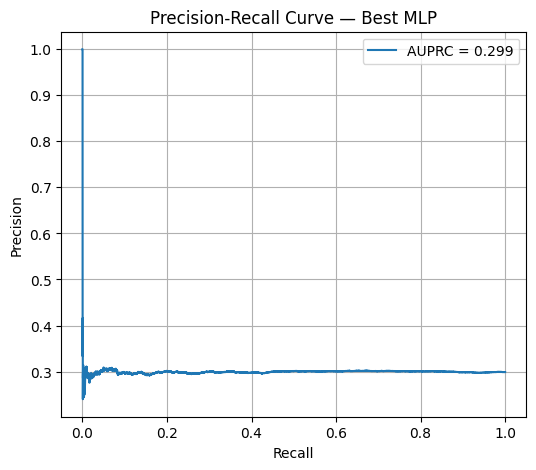

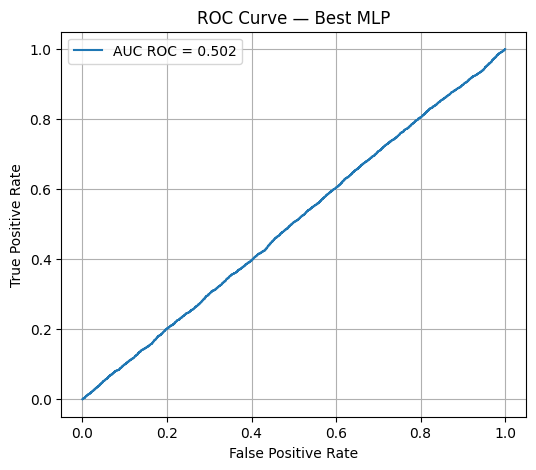

In [25]:
params_grid = {
    'hidden_layer_sizes': [(32,32), (64,64), (128,64)],
    'alpha': [0.001, 0.01, 0.05],
    'activation': ['relu', 'tanh']
}

nns = RandomizedSearchCV(
    estimator=MLPClassifier(
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.2,
        random_state=42
    ),
    param_distributions=params_grid,
    n_iter=20,
    scoring='average_precision',
    cv=5,
    verbose=2,
    n_jobs=-1
)

nns.fit(X_train_scaled, y_train)

print("Migliori parametri trovati:")
print(nns.best_params_)

best_mlp = nns.best_estimator_

y_pred = best_mlp.predict(X_val_scaled)
y_proba = best_mlp.predict_proba(X_val_scaled)[:,1]

# ROC
fpr, tpr, _ = roc_curve(y_val, y_proba)
auc_roc = auc(fpr, tpr)
print(f"AUC ROC su validation: {auc_roc:.4f}")

# PR
precision, recall, _ = precision_recall_curve(y_val, y_proba)
auprc = auc(recall, precision)
print(f"AUPRC su validation: {auprc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
print(f"TP: {cm[1,1]}, FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}, TN: {cm[0,0]}")
print("\nClassification Report:\n", classification_report(y_val, y_pred))



plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'AUPRC = {auprc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Best MLP')
plt.legend()
plt.grid(True)
plt.show()


#ROC PLOT
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC ROC = {auc_roc:.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Best MLP')
plt.legend()
plt.grid(True)
plt.show()



Nonostante l' utilizzo delle MLP , queste non hanno moostrato capacità predittive significative.  RandomizedSearch ha selezionato come migliore configurazione (32,32), alpha=0.01, activation='tanh', ma il modello risultante predice esclusivamente la classe negativa.

Questo comportamento è confermato da valori della curva AUC ROC equivalenti ad un classificatore casuale e AUPRC pari alla baseline della distribuzione delle classi.

La configurazione migliore valutata sul validation set mostra che il modello predice sempre la classe negativa, ottenendo un accuracy alta , per motivi legati allo sbilanciamento del dataset.

La MLP non riesce quindi a separare le classi nel dataset. Questo risultato è coerente con la natura sintetica del dataset, che non presenta pattern non lineari complessi né feature informative utili alla classe positiva. In assenza di segnali strutturati, la MLP converge verso la soluzione banale che minimizza la loss: predire sempre la classe maggioritaria.


--- Soglia = 0.2 ---
TP: 5981, FP: 14019
FN: 0, TN: 0


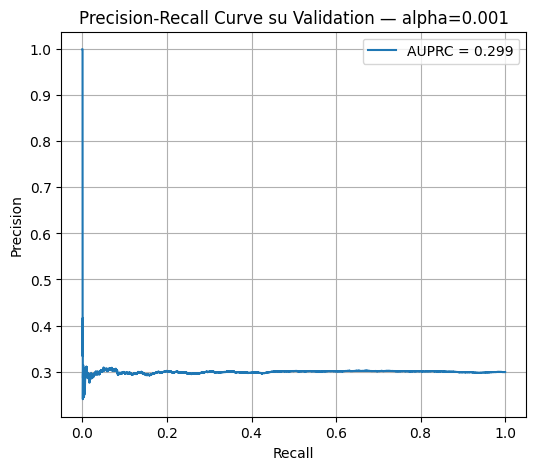

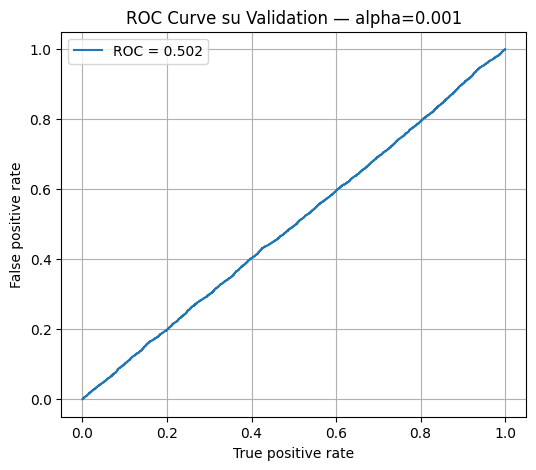

In [35]:
#Valutazione modello su test set
# Modello scelto LOGISTIC REgression per una questione puramente legata allo scneario clinico
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

#Normalizzazione dei dataset sui nuovi dati
scaler = MinMaxScaler()

X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_scaled        = scaler.transform(X_test)


# Inizializzo i pesi
W = np.zeros(X_train_full_scaled.shape[1])

max_iter = 3000
for _ in range(max_iter):
    grad = log_reg.vectorized_gradient(W, X_train_full_scaled, y_train_full)
    W = W - best_alpha * grad

probs_val = log_reg.sigmoid(X_test_scaled @ W)

y_hat = (probs_val >= best_threshold).astype(int)

print(f"\n--- Soglia = {best_threshold} ---")
cm = confusion_matrix(y_test, y_hat)
print(f"TP: {cm[1,1]}, FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}, TN: {cm[0,0]}")

# Plot PR curve
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'AUPRC = {auprc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve su Validation — alpha={alpha}')
plt.legend()
plt.grid(True)
plt.show()

#ROC PLOT
plt.figure(figsize=(6,5))
plt.plot(tpr, fpr, label=f'ROC = {auc_roc:.3f}')
plt.xlabel('True positive rate')
plt.ylabel('False positive rate')
plt.title(f'ROC Curve su Validation — alpha={alpha}')
plt.legend()
plt.grid(True)
plt.show()


L'Addestramento su testset ha dimostrato l'assenza di informazione discriminativa del dataset.

PCA


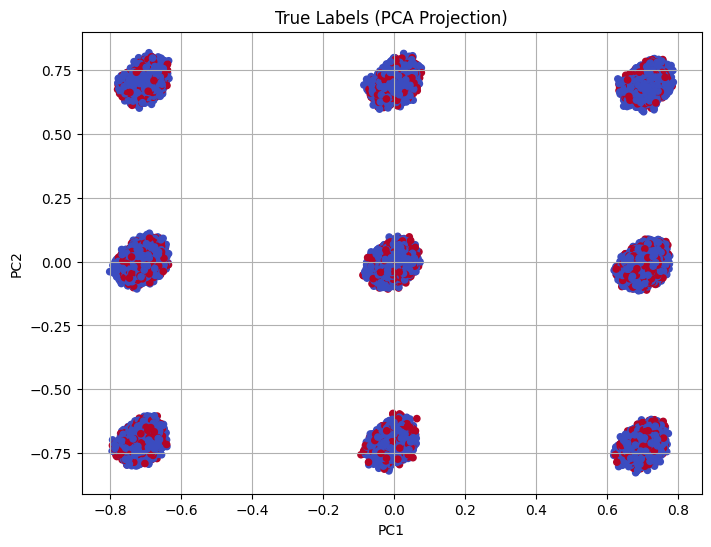

K-MEANS cluster (4)
cluster  target
0        0         0.700984
         1         0.299016
1        0         0.700409
         1         0.299591
2        0         0.698856
         1         0.301144
3        0         0.704331
         1         0.295669
Name: proportion, dtype: float64


In [51]:
#ANALISI UNSUOERVISED
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


print("PCA")

# Applico PCA a 2 componenti per visualizzare i cluster
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_full_scaled)

# Plot dei cluster confrontati con il target reale
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train_full, cmap="coolwarm", s=20)
plt.title("True Labels (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


print("K-MEANS cluster (4)")
kmeans = KMeans(n_clusters=4, random_state=42)
clusters_full = kmeans.fit_predict(X_train_full_scaled)

cluster_df = pd.DataFrame({"cluster": clusters_full, "target": y_train_full})
print(cluster_df.groupby("cluster")["target"].value_counts(normalize=True))






**ANALISI NON SUPERVISIONATA**

La proiezione PCA sulle direzioni di massima varianza, mostra masse compatte , con completa sovrapposizione dlele 2 classi. Questo indica l'assenza di direzioni discriminanti nello spazio delle features.

L'applicazione di K-means conferma la non esistenza di cluster naturali che corrispondono alle classi: all'interno dei 4 cluster considerati la distribuzione risultante rispetto alla variabile target era invariata (circa 70/30).


L’analisi non supervisionata conferma che il dataset non presenta cluster naturali né separabilità intrinseca tra le classi rispetto alla variabile target.